# Compare MNIST Inpainting Checkpoints

Loads checkpoints, picks one test image, and resamples the masked center patch from each model.

In [8]:
adamw_path = "diffusion/adamw.pt"
muon_path = "diffusion/muon.pt"

wgan_vanilla_path = "wgan/wganvanilla.pt"
wgan_path = "wgan/wgan.pt"

In [2]:
import torch
import matplotlib.pyplot as plt

from diffusion.data import get_dataloaders
from diffusion.model import Denoiser, make_scheduler, sample
from wgan.model import Generator

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

/opt/homebrew/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='mps')

In [3]:
def load_model(path):
    checkpoint = torch.load(path, map_location="cpu")
    args = checkpoint.get("args", {})

    model = Denoiser(t_dim=args.get("t_dim", 128)).to(device)
    model.load_state_dict(checkpoint.get("ema_model", checkpoint["model"]))

    model.eval()

    train_steps = args.get("train_steps", 1_000)
    inference_steps = args.get("inference_steps", 50)
    scheduler = make_scheduler(train_steps)

    return model, scheduler, inference_steps


adamw_model, adamw_scheduler, adamw_steps = load_model(adamw_path)
muon_model, muon_scheduler, muon_steps = load_model(muon_path)

In [4]:
def load_generator(path):
    checkpoint = torch.load(path, map_location="cpu")
    args = checkpoint.get("args", {})

    model = Generator(
        z_dim=args.get("z_dim", 100),
        base_channels=args.get("base_channels", 64),
        slope=args.get("leaky_slope", 0.2),
    ).to(device)
    model.load_state_dict(checkpoint["ema_generator"])
    model.eval()

    return model, args.get("z_dim", 100)

wgan_vanilla_model, wgan_vanilla_z_dim = load_generator(wgan_vanilla_path)
wgan_model, wgan_z_dim = load_generator(wgan_path)

In [5]:
def get_test_image(data_seed):
    _, _, test_loader = get_dataloaders(batch_size=1, seed=data_seed)
    x, y = next(iter(test_loader))

    original = x[:, :1].clone()
    original[:, :, 7:21, 7:21] = y

    return x.to(device), original.to(device)


In [6]:
def generate_samples(model, scheduler, steps, x, num_times, model_seed):
    x_repeat = x.repeat(num_times, 1, 1, 1)
    torch.manual_seed(model_seed)
    return sample(model, x_repeat, scheduler, steps=steps)


def generate_gan_samples(model, z_dim, x, num_times, model_seed):
    masked = x[:, :1].repeat(num_times, 1, 1, 1)
    mask = x[:, 1:2].repeat(num_times, 1, 1, 1)
    torch.manual_seed(model_seed)
    z = torch.randn(num_times, z_dim, device=device)
    with torch.no_grad():
        return model(masked, mask, z)

def show_image(ax, image, title):
    image = image.detach().cpu().squeeze()
    image = ((image + 1) / 2).clamp(0, 1)
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")


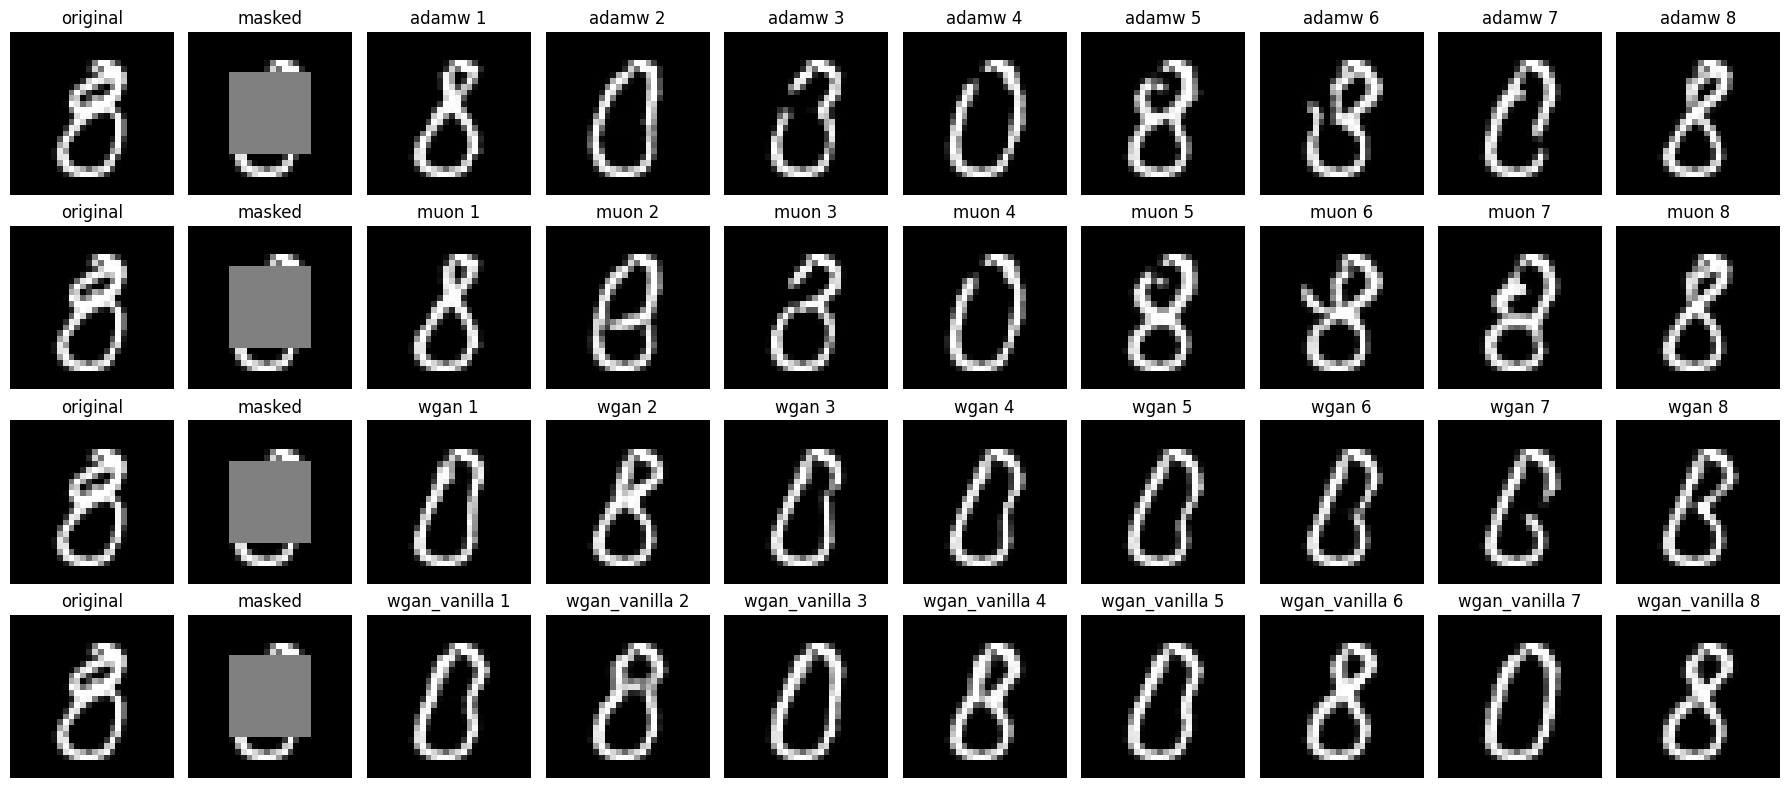

In [9]:
data_seed = 14
model_seed = 0
num_times = 8
x, original = get_test_image(data_seed)

adamw_samples = generate_samples(
    adamw_model, adamw_scheduler, adamw_steps, x, num_times, model_seed
)
muon_samples = generate_samples(
    muon_model, muon_scheduler, muon_steps, x, num_times, model_seed
)

wgan_vanilla_samples = generate_gan_samples(
    wgan_vanilla_model, wgan_vanilla_z_dim, x, num_times, model_seed
)
wgan_samples = generate_gan_samples(
    wgan_model, wgan_z_dim, x, num_times, model_seed
)


rows = [
    ("adamw", adamw_samples),
    ("muon", muon_samples),
    ("wgan", wgan_samples),
    ("wgan_vanilla", wgan_vanilla_samples),
]

fig, axes = plt.subplots(
    len(rows), num_times + 2, figsize=(1.8 * (num_times + 2), 2 * len(rows))
)

for r, (name, samples) in enumerate(rows):
    show_image(axes[r, 0], original[0], "original")
    show_image(axes[r, 1], x[0, :1], "masked")
    for i in range(num_times):
        show_image(axes[r, i + 2], samples[i], f"{name} {i + 1}")

plt.tight_layout()